# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

Dataset: 200 albums and 4 columns
Missing values: 0


,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


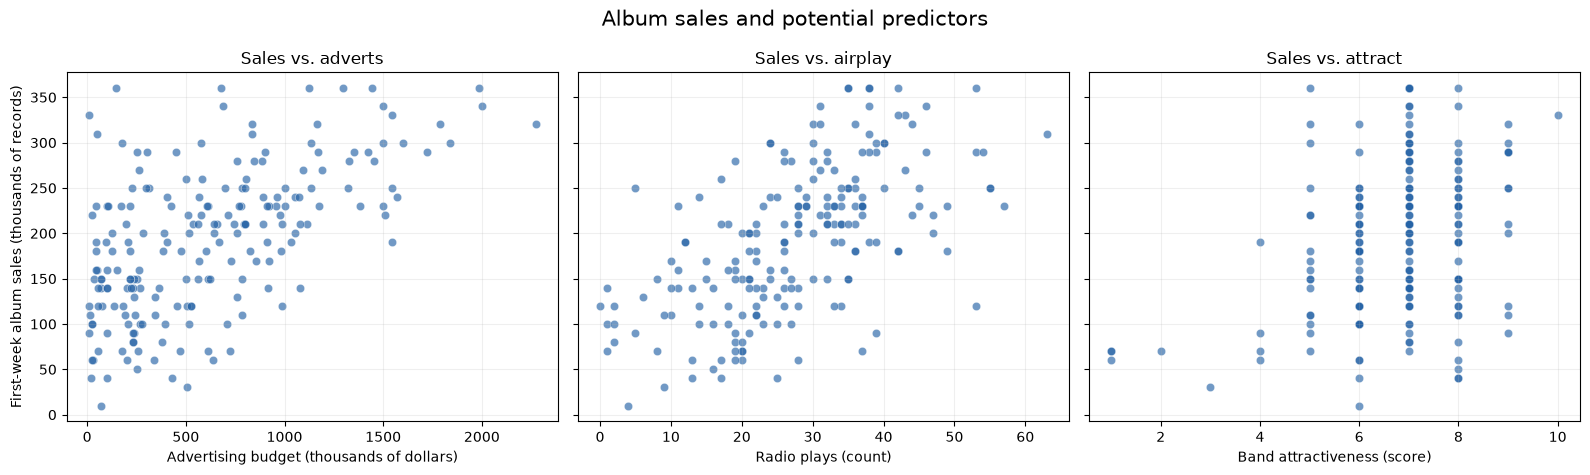

adverts    0.578488
airplay    0.598919
attract    0.326111
Name: Correlation with sales, dtype: float64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

albums = pd.read_csv("album_sales.csv")
print(f"Dataset: {albums.shape[0]} albums and {albums.shape[1]} columns")
print(f"Missing values: {albums.isna().sum().sum()}")
display(albums.head())

predictors = ["adverts", "airplay", "attract"]
labels = ["Advertising budget (thousands of dollars)",
          "Radio plays (count)", "Band attractiveness (score)"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, predictor, label in zip(axes, predictors, labels):
    ax.scatter(albums[predictor], albums["sales"], alpha=0.65,
               color="#2563a6", edgecolors="white", linewidths=0.4)
    ax.set_xlabel(label)
    ax.set_title(f"Sales vs. {predictor}")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("First-week album sales (thousands of records)")
fig.suptitle("Album sales and potential predictors", fontsize=15)
fig.tight_layout()
plt.show()

display(albums.corr()["sales"].loc[predictors].rename("Correlation with sales"))

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

All three scatterplots show positive associations with first-week album sales, but their strengths differ.

- **Sales and advertising:** Sales generally increase as advertising spending increases. The relationship is moderately positive (Pearson r = 0.578), with substantial scatter, especially at lower budgets. Advertising alone does not account for all differences in sales.
- **Sales and airplay:** Albums played more often on the radio tend to have higher sales. This is the clearest positive linear relationship of the three (r = 0.599).
- **Sales and attractiveness:** Higher attractiveness scores tend to accompany higher sales, but the relationship is weaker (r = 0.326). The vertical groups of points occur because attractiveness is measured with discrete scores.

These are associations; the plots alone do not establish that any predictor causes higher sales.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [2]:
y = albums["sales"]
X_simple = sm.add_constant(albums[["adverts"]])
model1 = sm.OLS(y, X_simple).fit()
print(model1.summary())
print(f"\nF-statistic: {model1.fvalue:.4f}")
print(f"Overall model p-value: {model1.f_pvalue:.6e}")
print(f"R-squared: {model1.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        19:20:56   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The advertising-only model has **F(1, 198) = 99.587** and an overall **p-value of 2.942e-19**, which is below 0.05. The F-test compares this model against an intercept-only model; its null hypothesis is that the advertising slope is zero. We reject that null hypothesis and conclude that advertising is statistically associated with sales.

However, statistical significance does not by itself make a model a strong predictor. Its **R² = 0.3346**, so advertising explains approximately **33.46%** of the observed variation in sales. This is a useful but limited fit: much of the variation remains unexplained, and prediction accuracy on new albums has not been tested.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [3]:
intercept = model1.params["const"]
adverts_coefficient = model1.params["adverts"]
print(f"Intercept: {intercept:.6f}")
print(f"Advertising coefficient: {adverts_coefficient:.6f}")
print(f"Sales (thousands) = {intercept:.6f} + {adverts_coefficient:.6f} * adverts (thousands of dollars)")

advertising_dollars = 135_000
advertising_thousands = advertising_dollars / 1_000
predicted_sales_thousands = intercept + adverts_coefficient * advertising_thousands
predicted_records = predicted_sales_thousands * 1_000
print(f"\nAdvertising budget: ${advertising_dollars:,.0f} = {advertising_thousands:g} thousand dollars")
print(f"Predicted first-week sales: {predicted_sales_thousands:.3f} thousand records")
print(f"Predicted first-week sales: approximately {predicted_records:,.0f} records")

Intercept: 134.139938
Advertising coefficient: 0.096124
Sales (thousands) = 134.139938 + 0.096124 * adverts (thousands of dollars)

Advertising budget: $135,000 = 135 thousand dollars
Predicted first-week sales: 147.117 thousand records
Predicted first-week sales: approximately 147,117 records


For a **$135,000** advertising budget, substitute **135** into the fitted equation:

Predicted sales (thousands) = 134.139938 + (0.096124 × 135) = **147.117**.

The model therefore predicts approximately **147,117 records sold in the first week**. This is a point estimate, not a guaranteed sales total. The intercept represents predicted sales at zero advertising; the slope represents the predicted change in thousands of records for each additional $1,000 of advertising.

### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [4]:
X_multiple = sm.add_constant(albums[["adverts", "airplay", "attract"]])
model2 = sm.OLS(y, X_multiple).fit()
print(model2.summary())

comparison = pd.DataFrame({
    "Model": ["Model 1: advertising", "Model 2: advertising, airplay, attractiveness"],
    "R-squared": [model1.rsquared, model2.rsquared],
    "Adjusted R-squared": [model1.rsquared_adj, model2.rsquared_adj],
    "F-statistic": [model1.fvalue, model2.fvalue],
    "Overall p-value": [model1.f_pvalue, model2.f_pvalue]
})
display(comparison.set_index("Model"))

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        19:20:56   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

,R-squared,Adjusted R-squared,F-statistic,Overall p-value
Model,,,,
Model 1: advertising,0.334648,0.331288,99.586871,2.941980e-19
"Model 2: advertising, airplay, attractiveness",0.664668,0.659535,129.498273,2.875535e-46


We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

**Model 2, the multiple regression model, provides the better fit to these data.**

| Measure | Model 1: advertising | Model 2: all three predictors |
|---|---:|---:|
| R² | 0.3346 | 0.6647 |
| Adjusted R² | 0.3313 | 0.6595 |
| Overall F-statistic | 99.587 | 129.498 |
| Overall model p-value | 2.942e-19 | 2.876e-46 |

Both models have overall p-values below 0.05. Model 2 explains approximately **66.47%** of the observed variation in sales, compared with **33.46%** for Model 1. Its adjusted R² also increases substantially, so the improvement persists after accounting for the additional predictors.

In Model 2, advertising (p = 5.055e-26), airplay (p = 1.326e-25), and attractiveness (p = 9.492e-06) each have a positive coefficient and a p-value below 0.05, holding the other predictors fixed. This supports including all three predictors.

I would select Model 2 based on the assignment's fit criteria. R² normally cannot decrease when predictors are added, so adjusted R² is useful supporting evidence. This comparison establishes a better fit to the observed sample; performance on new albums would require separate validation.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name